# **Import Libraries**

In [38]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.cluster import KMeans

# **Load the data**

In [3]:
def extract_zip_file(file_path, extract_to):
    try:
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)
            print(f"Extracted ZIP: {file_path}")
        return True
    except Exception as e:
        print(f"Error extracting {file_path}: {e}")
        return False
# Usage:
initial_file = '/content/Image_Brain_Tumors.zip'
destination = '/content/Images_Brain_Unzipped'
extract_zip_file(initial_file, destination)

Extracted ZIP: /content/Image_Brain_Tumors.zip


True

# **Display sample of the images**

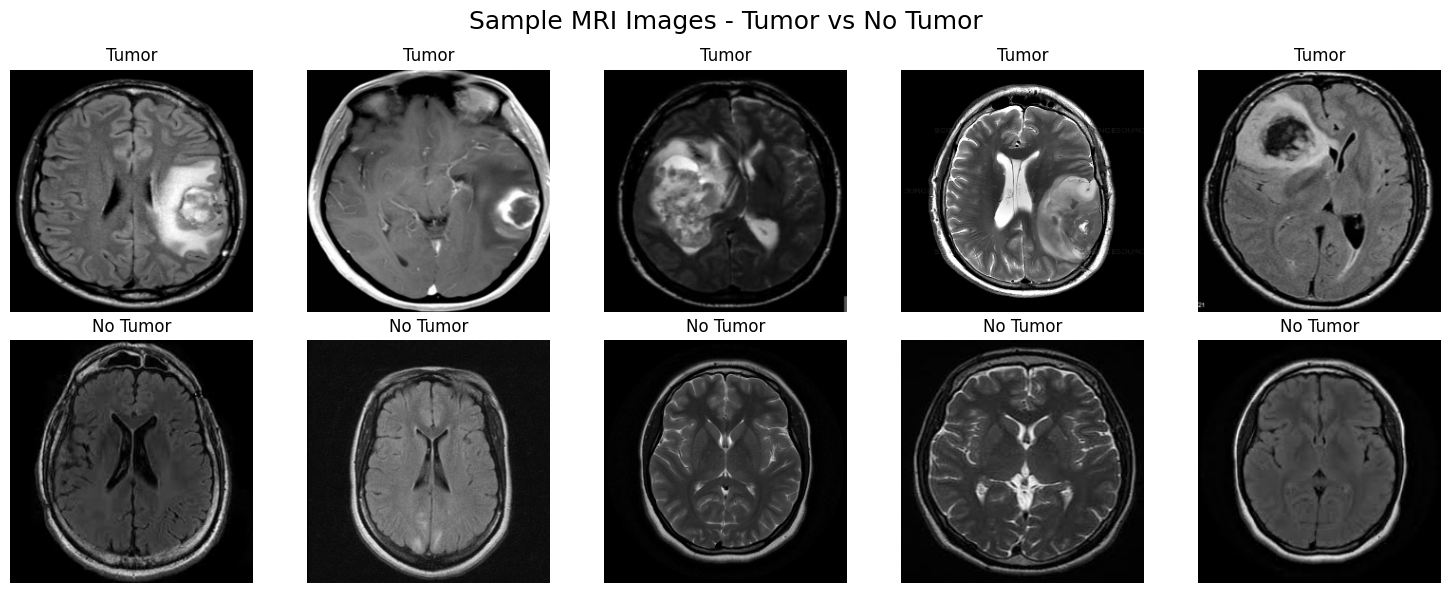

In [27]:
# Load a few random images (e.g., 5) from each class folder
def load_random_samples(folder_path, label, count=5):
    images = []
    if not os.path.exists(folder_path):
        print(f"Error: Directory not found: {folder_path}")
        return images
    all_files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    random_files = random.sample(all_files, min(count, len(all_files)))  # pick random files

    for filename in random_files:
        path = os.path.join(folder_path, filename)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (256, 256))
            images.append((img, label))
    return images

# Load 5 random tumor images and 5 random normal images
tumor_samples = load_random_samples('/content/Images_Brain_Unzipped/archive/yes', "Tumor", count=5)
normal_samples = load_random_samples('/content/Images_Brain_Unzipped/archive/no', "No Tumor", count=5)

# Plot 5 tumor images in top row, 5 normal images in bottom row
plt.figure(figsize=(15, 6))

# Tumor images on top row
for i, (img, label) in enumerate(tumor_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(label)
    plt.axis('off')

# Normal images on bottom row
for i, (img, label) in enumerate(normal_samples):
    plt.subplot(2, 5, i + 6)  # 6 to 10 positions
    plt.imshow(img, cmap='gray')
    plt.title(label)
    plt.axis('off')

plt.suptitle("Sample MRI Images - Tumor vs No Tumor", fontsize=18)
plt.tight_layout()
plt.show()


# **Load the Images**

In [30]:
def load_images(folder_path, size=(256, 256)):
    images = []
    for filename in os.listdir(folder_path):
        img = cv2.imread(os.path.join(folder_path, filename), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, size)
            images.append(img)
    return images

tumor_images = load_images('/content/Images_Brain_Unzipped/archive/yes')
normal_images = load_images('/content/Images_Brain_Unzipped/archive/no')

# **Function to display the images**

In [56]:
def display_sample(images, labels, title="", color=False):

    num_images = min(5, len(images))
    plt.figure(figsize=(15, 4))

    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        img = images[i]

        if color:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img)
        else:
            plt.imshow(img, cmap='gray')

        plt.title(f"{title} #{i + 1}\n({labels[i]})", fontsize=10)
        plt.axis('off')

    plt.suptitle(title, fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()


# **Display the original images**

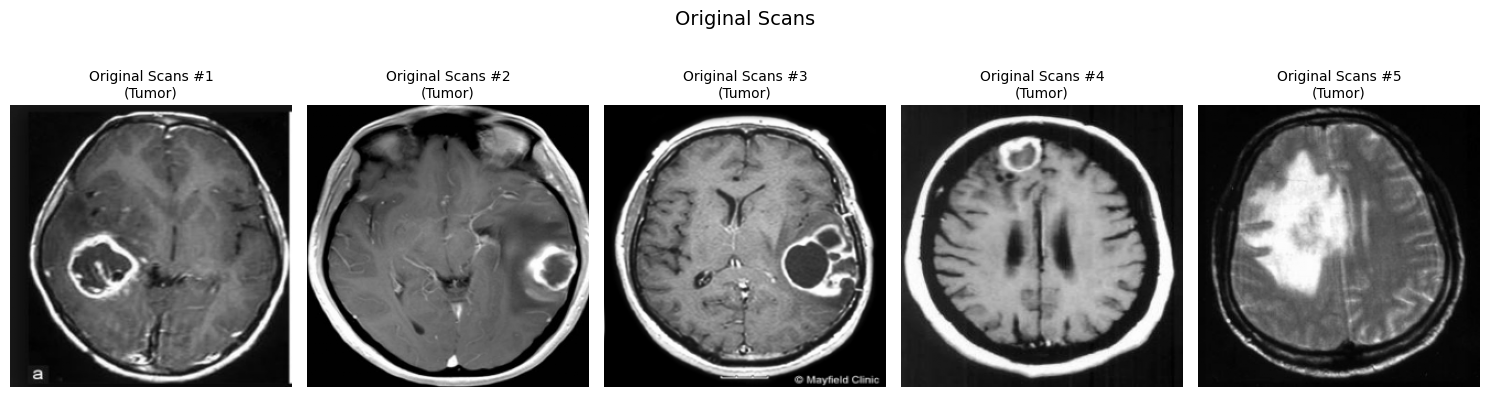

In [58]:
selected_images = tumor_images[:5]
labels = ['Tumor'] * len(selected_images)

# Display originals
display_sample(selected_images, labels, "Original Scans")

# **Convert to Grayscale**

In [41]:
def to_grayscale(image):
    if len(image.shape) == 3:
        return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image.copy()


# **Apply Median Filtering**

In [42]:
def apply_median_filter(gray_image, ksize=5):
    return cv2.medianBlur(gray_image, ksize)


# **Reshape for Clustering**

In [43]:
def reshape_for_kmeans(image):
    return image.reshape((-1, 1)).astype(np.float32)


# **Apply K-Means Clustering**

In [44]:
from sklearn.cluster import KMeans

def apply_kmeans(pixel_values, num_clusters=4):
    kmeans = KMeans(n_clusters=num_clusters, n_init=10, random_state=42)
    kmeans.fit(pixel_values)
    return kmeans


# **Get Tumor Mask**

In [62]:
def get_tumor_mask(labels, centers, shape):
    tumor_cluster = np.argmax(centers.flatten())
    clustered = labels.reshape(shape)
    tumor_mask = (clustered == tumor_cluster).astype(np.uint8) * 255
    return tumor_mask


# **A Function to Remove the remainings of Brain edges from Tumor mask**

In [60]:
def remove_border_touching_components(mask, border_margin=10):
    # Ensure binary mask 0/255 uint8
    bin_mask = (mask > 127).astype(np.uint8)

    # Connected components labeling (background=0)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(bin_mask, connectivity=8)

    height, width = bin_mask.shape
    cleaned_mask = np.zeros_like(bin_mask, dtype=np.uint8)

    for label in range(1, num_labels):  # skip background label 0
        x, y, w, h, area = stats[label]

        # Check if component touches or is within border_margin of any border
        touches_border = (x <= border_margin or
                          y <= border_margin or
                          (x + w) >= (width - border_margin) or
                          (y + h) >= (height - border_margin))

        if not touches_border:
            # Keep this component
            cleaned_mask[labels == label] = 1

    # Convert back to 0/255 uint8 mask
    return cleaned_mask * 255

# **Segmenting the Brain Tumor**

In [46]:
def segment_brain_tumor(image, num_clusters=4, border_margin=10):
    gray = to_grayscale(image)
    preprocessed = apply_median_filter(gray)
    pixels = reshape_for_kmeans(preprocessed)

    kmeans = apply_kmeans(pixels, num_clusters=num_clusters)
    tumor_mask = get_tumor_mask(kmeans.labels_, kmeans.cluster_centers_, preprocessed.shape)

    cleaned_mask = remove_border_touching_components(tumor_mask, border_margin=border_margin)
    return preprocessed, tumor_mask, cleaned_mask



# **Choose Largest Filled Tumor Contour Mask**

In [47]:
def get_largest_filled_contour_mask(binary_mask, dilation_kernel_size=15):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilation_kernel_size, dilation_kernel_size))
    dilated_mask = cv2.dilate(binary_mask, kernel, iterations=1)

    contours, _ = cv2.findContours(dilated_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros_like(binary_mask)

    largest_contour = max(contours, key=cv2.contourArea)

    filled_mask = np.zeros_like(binary_mask)
    cv2.drawContours(filled_mask, [largest_contour], contourIdx=-1, color=255, thickness=cv2.FILLED)
    return filled_mask


# **Overlay Tumor on Original Image**

In [50]:
def highlight_tumors(original, mask):
    highlighted = cv2.cvtColor(original, cv2.COLOR_GRAY2BGR)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Thick colored edge + transparent fill
    cv2.drawContours(highlighted, contours, -1, (0,255,255), 3)
    overlay = highlighted.copy()
    cv2.drawContours(overlay, contours, -1, (0,0,255), -1)
    highlighted = cv2.addWeighted(overlay, 0.3, highlighted, 0.7, 0)

    return highlighted


# **Display the Images Sequence**

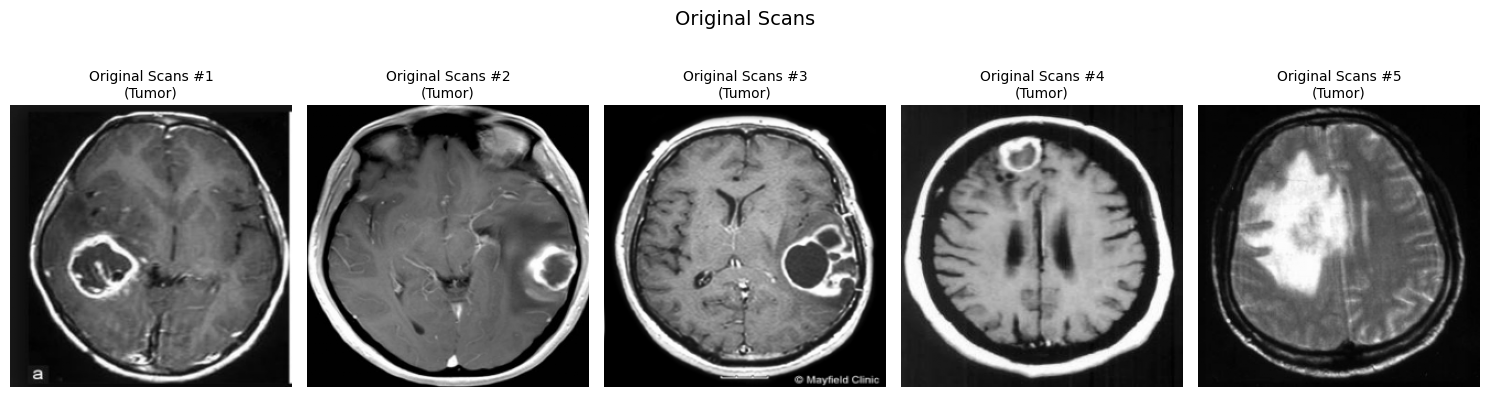

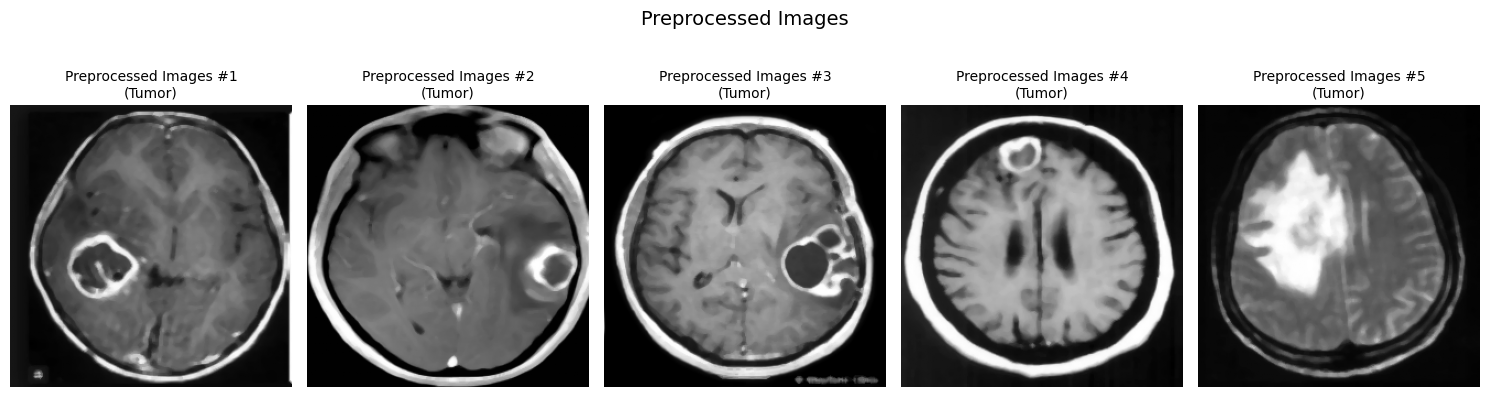

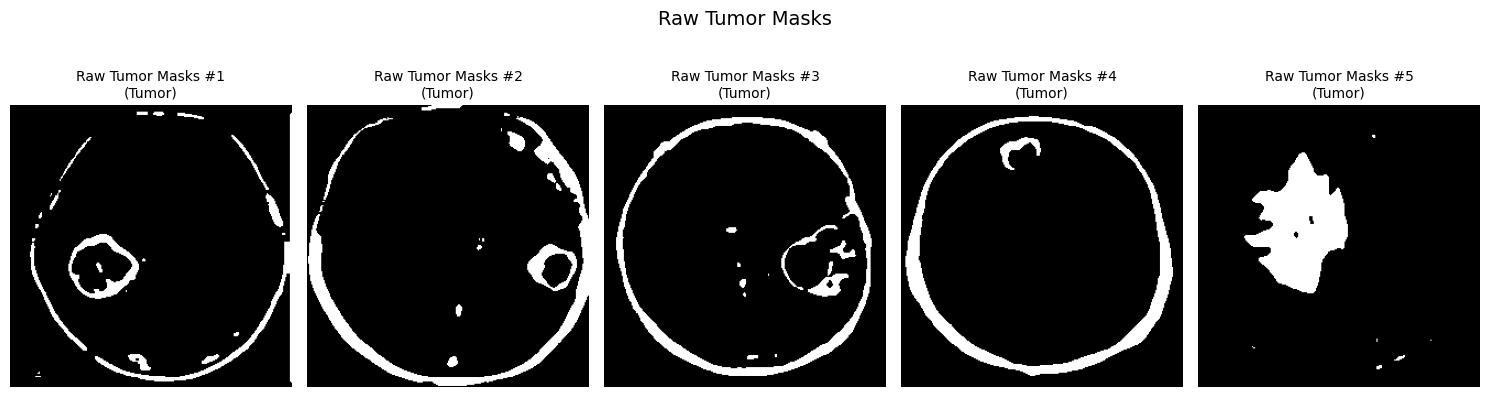

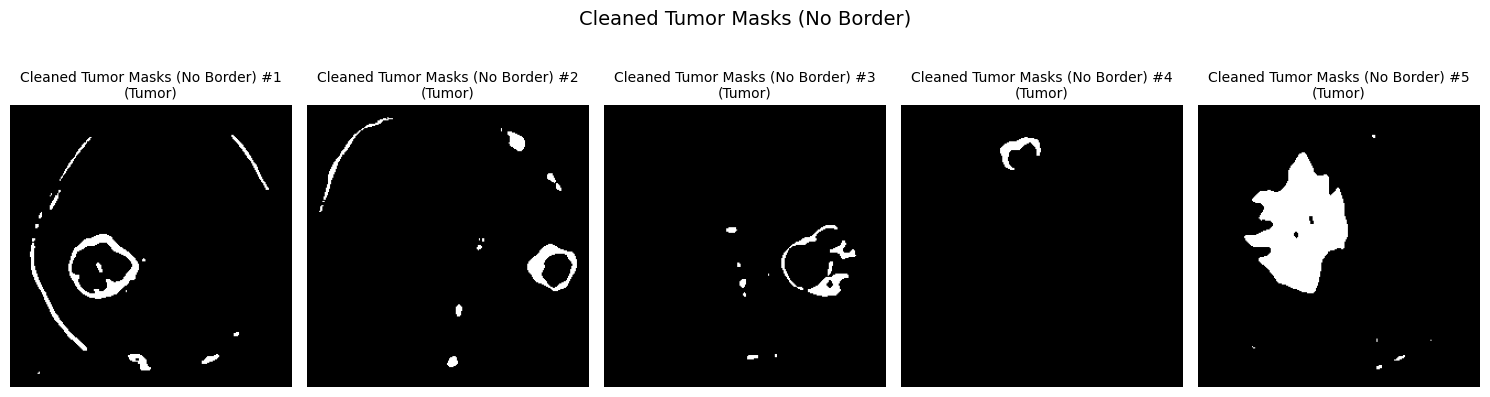

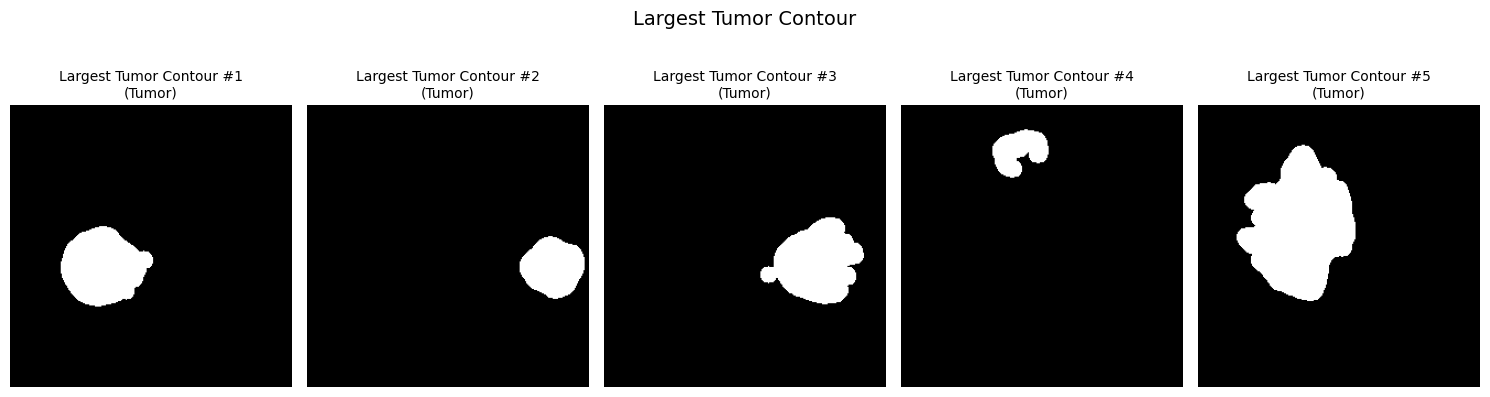

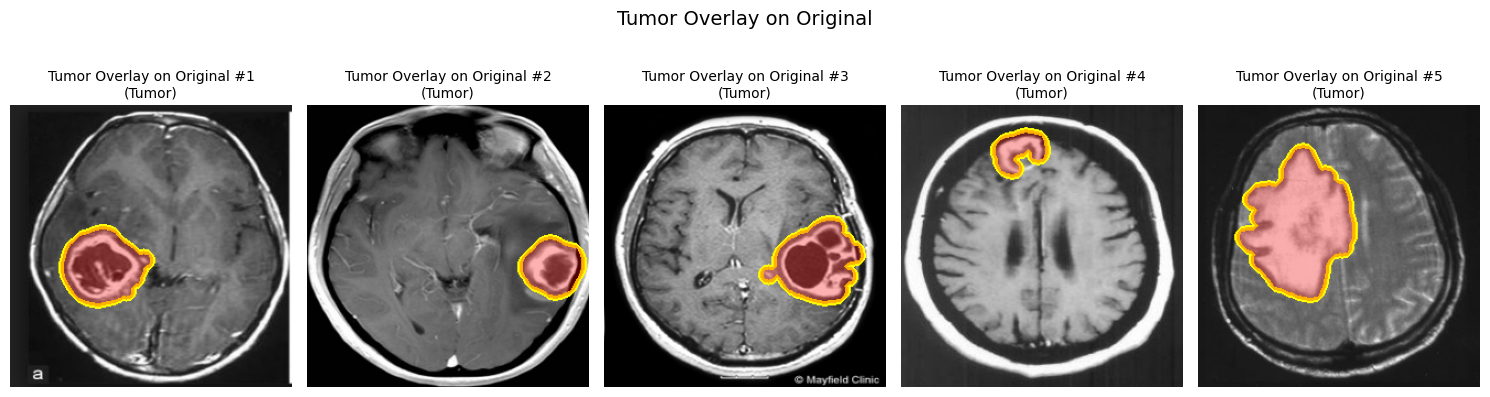

In [59]:
# Select sample tumor images
selected_images = tumor_images[:5]
labels = ['Tumor'] * len(selected_images)

# Display originals
display_sample(selected_images, labels, "Original Scans")

# Process and collect outputs
results = []
for img in selected_images:
    preprocessed, raw_mask, cleaned_mask = segment_brain_tumor(img)
    largest_mask = get_largest_filled_contour_mask(cleaned_mask)
    highlighted = highlight_tumors(img, largest_mask)
    results.append((preprocessed, raw_mask, cleaned_mask, largest_mask, highlighted))

# Display each stage
display_sample([r[0] for r in results], labels, "Preprocessed Images")
display_sample([r[1] for r in results], labels, "Raw Tumor Masks")
display_sample([r[2] for r in results], labels, "Cleaned Tumor Masks (No Border)")
display_sample([r[3] for r in results], labels, "Largest Tumor Contour")
display_sample([r[4] for r in results], labels, "Tumor Overlay on Original", color=True)
